# Đánh giá ảnh hưởng của tiền xử lý văn bản MXH đến hiệu quả phân loại cảm xúc PhoBERT (UIT-VSMEC)

Notebook này cài đặt đầy đủ pipeline thực nghiệm ablation **P0–P4** mô tả trong đề cương:

| Cấu hình | Nội dung |
|---|---|
| P0 | Không tiền xử lý (baseline) |
| P1 | Chuẩn hóa từ viết tắt / teencode |
| P2 | Chuẩn hóa emoji → mô tả bằng lời |
| P3 | Loại bỏ URL/@mention, chuẩn hóa ký tự & dấu câu lặp |
| P4 | Kết hợp P1+P2+P3 |

**Cách dùng trên Google Colab:**
1. `Runtime → Change runtime type → GPU` (chọn T4 trở lên).
2. Chạy lần lượt từng cell từ trên xuống.
3. Ở cell **"Tải dữ liệu"**, upload file `UIT-VSMEC.zip` khi được yêu cầu.
4. Mặc định notebook chạy **5 cấu hình × 3 seed = 15 lượt fine-tune**. Có thể giảm `SEEDS` hoặc `CONFIGS` ở cell cấu hình để chạy thử nhanh trước.


#1 CÀI ĐẶT THƯ VIỆN

In [1]:
# ==== 1. CÀI ĐẶT THƯ VIỆN ====
!pip -q install transformers datasets accelerate evaluate py_vncorenlp scikit-learn openpyxl matplotlib seaborn scipy


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.9 MB/s eta 0:00:00


In [2]:
# ==== 1b. MOUNT GOOGLE DRIVE (lưu checkpoint & kết quả để chạy tiếp nếu bị ngắt) ====
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = "/content/drive/MyDrive/PhoBERT_UIT_VSMEC"
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/results", exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/cached_datasets", exist_ok=True)

print("Toàn bộ dữ liệu đã tiền xử lý, checkpoint và kết quả sẽ được lưu tại:")
print(DRIVE_DIR)
print("=> Nếu Colab bị ngắt kết nối, chỉ cần mở lại notebook, chạy lại từ đầu:")
print("   các bước đã hoàn tất (tiền xử lý, các lượt huấn luyện đã xong) sẽ TỰ ĐỘNG được bỏ qua.")


Mounted at /content/drive
Toàn bộ dữ liệu đã tiền xử lý, checkpoint và kết quả sẽ được lưu tại:
/content/drive/MyDrive/PhoBERT_UIT_VSMEC
=> Nếu Colab bị ngắt kết nối, chỉ cần mở lại notebook, chạy lại từ đầu:
   các bước đã hoàn tất (tiền xử lý, các lượt huấn luyện đã xong) sẽ TỰ ĐỘNG được bỏ qua.


#đánh giá thay đổi P2 và P4

In [ ]:
# ==== DỌN CACHE CŨ CỦA P2, P4 ĐỂ CHẠY LẠI VỚI EMOJI_DICT MỚI ====
import shutil, json, os

for cfg in ["P2", "P4"]:
    # xóa dữ liệu đã tiền xử lý cache trên Drive
    shutil.rmtree(f"{DRIVE_DIR}/cached_datasets/{cfg}", ignore_errors=True)

# xóa kết quả cũ của P2, P4 khỏi all_results.json để pipeline chạy lại từ đầu
results_json_path = f"{DRIVE_DIR}/results/all_results.json"
if os.path.exists(results_json_path):
    with open(results_json_path, "r", encoding="utf-8") as f:
        old_results = json.load(f)
    new_results = [r for r in old_results if r["config"] not in ["P2", "P4"]]
    with open(results_json_path, "w", encoding="utf-8") as f:
        json.dump(new_results, f, ensure_ascii=False, indent=2)
    print(f"Đã xóa {len(old_results) - len(new_results)} kết quả cũ của P2/P4, giữ lại {len(new_results)}.")

# xóa per-class csv cũ của P2, P4
per_class_dir = f"{DRIVE_DIR}/results/per_class"
for seed in [42, 123, 2024]:
    for cfg in ["P2", "P4"]:
        f = f"{per_class_dir}/{cfg}_seed{seed}.csv"
        if os.path.exists(f):
            os.remove(f)

print("Đã dọn xong. Chạy lại từ cell tiền xử lý (cell 3) trở đi.")

Đã dọn xong. Chạy lại từ cell tiền xử lý (cell 3) trở đi.


#2 TẢI DỮ LIỆU UIT-VSMEC

In [3]:
# ==== 2. TẢI DỮ LIỆU UIT-VSMEC ====
# Upload file UIT-VSMEC.zip (định dạng HuggingFace DatasetDict: train/validation/test)
from google.colab import files
import zipfile, os

print("Vui lòng chọn file UIT-VSMEC.zip để upload...")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
os.makedirs("vsmec_raw", exist_ok=True)
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("vsmec_raw")

print("Đã giải nén vào ./vsmec_raw")


Vui lòng chọn file UIT-VSMEC.zip để upload...


Saving UIT-VSMEC.zip to UIT-VSMEC.zip
Đã giải nén vào ./vsmec_raw


In [4]:
from datasets import load_from_disk
import datasets as _hf_datasets

# --- Vá lỗi tương thích datasets <-> torchvision trên Colab ---
# datasets cố import torchvision.io.VideoReader để hỗ trợ dữ liệu video,
# nhưng bản torchvision hiện tại trên Colab đã loại bỏ class này, gây lỗi:
#   ImportError: cannot import name 'VideoReader' from 'torchvision.io'
# Tắt kiểm tra này vì đề tài không dùng dữ liệu video.
_hf_datasets.config.TORCHVISION_AVAILABLE = False

raw_ds = load_from_disk("vsmec_raw")
print(raw_ds)
print(raw_ds["train"][0])

LABELS = sorted(set(raw_ds["train"]["Emotion"]))
print("Nhãn cảm xúc:", LABELS)


DatasetDict({
    train: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 5548
    })
    validation: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 686
    })
    test: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 693
    })
})
{'Sentence': 'cho mình xin bài nhạc tên là gì với ạ', 'Emotion': 'Other'}
Nhãn cảm xúc: ['Anger', 'Disgust', 'Enjoyment', 'Fear', 'Other', 'Sadness', 'Surprise']


#3 MODULE TIỀN XỬ LÝ P0–P4

In [5]:
# ==== 3. MODULE TIỀN XỬ LÝ P0–P4 ====
import re

TEENCODE_DICT = {
    "ko": "không", "k": "không", "hông": "không", "hok": "không", "khum": "không",
    "dc": "được", "đc": "được",
    "mik": "mình", "mk": "mình",
    "bít": "biết", "bik": "biết",
    "j": "gì", "z": "vậy", "v": "vậy",
    "ntn": "như thế nào",
    "vs": "với",
    "nch": "nói chuyện",
    "ib": "nhắn tin",
    "mng": "mọi người", "mn": "mọi người",
    "trc": "trước",
    "r": "rồi", "rùi": "rồi",
    "ny": "người yêu",
    "add": "kết bạn",
    "cmt": "bình luận",
    "th": "thằng",
    "hs": "học sinh", "gv": "giáo viên", "sv": "sinh viên",
    "fb": "facebook",
    "tks": "cảm ơn", "thanks": "cảm ơn", "thank": "cảm ơn",
    "sr": "xin lỗi", "sorry": "xin lỗi",
    "ok": "được", "oke": "được", "okie": "được",
    "clgt": "cái gì thế",
    "kb": "kết bạn",
    "tl": "trả lời",
    "dt": "điện thoại",
    "nt": "nhắn tin",
    "hnay": "hôm nay",
    "hqua": "hôm qua",
}

EMOJI_DICT = {
    "😂": "cười", "🤣": "cười", "😆": "cười", "😄": "cười", "😃": "cười", "😁": "cười",
    "😍": "yêu thích", "🥰": "yêu thích", "😘": "yêu thích", "❤️": "yêu thích", "❤": "yêu thích",
    "😡": "tức giận", "🤬": "tức giận", "😠": "tức giận",
    "😢": "buồn", "😭": "buồn", "🙁": "buồn", "☹️": "buồn", "😔": "buồn",
    "😱": "sợ hãi", "😨": "sợ hãi", "😰": "sợ hãi",
    "😲": "ngạc nhiên", "😮": "ngạc nhiên", "😯": "ngạc nhiên", "😳": "ngạc nhiên",
    "🤢": "ghê tởm", "🤮": "ghê tởm", "😷": "ghê tởm",
    "😊": "vui vẻ", "🙂": "vui vẻ", "😀": "vui vẻ",
    "👍": "đồng ý", "👎": "không đồng ý",
}

URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+|\S+\.(?:com|vn|net|org)\S*)", re.IGNORECASE)
MENTION_PATTERN = re.compile(r"@[\w\.]+")
REPEAT_CHAR_PATTERN = re.compile(r"(.)\1{2,}")
REPEAT_PUNCT_PATTERN = re.compile(r"([!?.,])\1{1,}")
MULTISPACE_PATTERN = re.compile(r"\s+")


def normalize_abbreviations(text):
    tokens = text.split()
    out = []
    for tok in tokens:
        m = re.match(r"^([\wÀ-ỹ]+)([^\wÀ-ỹ]*)$", tok, re.UNICODE)
        if m:
            core, suffix = m.group(1), m.group(2)
            key = core.lower()
            if key in TEENCODE_DICT:
                core = TEENCODE_DICT[key]
            out.append(core + suffix)
        else:
            out.append(tok)
    return " ".join(out)


def normalize_emoji(text):
    out = text
    for emo, desc in EMOJI_DICT.items():
        out = out.replace(emo, f" {desc} ")
    return MULTISPACE_PATTERN.sub(" ", out).strip()


def remove_noise_chars(text):
    out = URL_PATTERN.sub(" ", text)
    out = MENTION_PATTERN.sub(" ", out)
    out = REPEAT_CHAR_PATTERN.sub(lambda m: m.group(1) * 2, out)
    out = REPEAT_PUNCT_PATTERN.sub(lambda m: m.group(1), out)
    return MULTISPACE_PATTERN.sub(" ", out).strip()


def apply_config(text, config):
    if text is None:
        return ""
    text = str(text).strip()
    if config == "P0":
        out = text
    elif config == "P1":
        out = normalize_abbreviations(text)
    elif config == "P2":
        out = normalize_emoji(text)
    elif config == "P3":
        out = remove_noise_chars(text)
    elif config == "P4":
        out = normalize_abbreviations(text)
        out = normalize_emoji(out)
        out = remove_noise_chars(out)
    else:
        raise ValueError(f"Cấu hình không hợp lệ: {config}")
    return MULTISPACE_PATTERN.sub(" ", out).strip()


CONFIGS = ["P0", "P1", "P2", "P3", "P4"]

# --- kiểm tra nhanh trên vài câu thật của UIT-VSMEC ---
for s in raw_ds["train"]["Sentence"][:3]:
    print("-" * 80)
    for cfg in CONFIGS:
        print(f"[{cfg}]", apply_config(s, cfg))


--------------------------------------------------------------------------------
[P0] cho mình xin bài nhạc tên là gì với ạ
[P1] cho mình xin bài nhạc tên là gì với ạ
[P2] cho mình xin bài nhạc tên là gì với ạ
[P3] cho mình xin bài nhạc tên là gì với ạ
[P4] cho mình xin bài nhạc tên là gì với ạ
--------------------------------------------------------------------------------
[P0] cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡
[P1] cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡
[P2] cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh tức giận
[P3] cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡
[P4] cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh tức giận
--------------------------------------------------------------------------------
[P0] lo học đi . yêu đương lol gì hay lại thích học sinh học
[P1] lo học đi . yêu đương lol gì hay lại thích học sinh học
[P2] lo học đi . yêu đương lol gì hay lại thích học sinh học
[P3] lo học đi . yêu đươn

#4 TÁCH TỪ TIẾNG VIỆT

In [6]:
# ==== 4. TÁCH TỪ TIẾNG VIỆT (VnCoreNLP — bắt buộc cho PhoBERT) ====
import os
import py_vncorenlp

VNCORENLP_DIR = os.path.abspath("vncorenlp")
os.makedirs(VNCORENLP_DIR, exist_ok=True)

# Chỉ tải model nếu chưa có (tránh tải lại/ghi log thừa mỗi lần chạy)
if not os.path.exists(os.path.join(VNCORENLP_DIR, "VnCoreNLP-1.2.jar")):
    py_vncorenlp.download_model(save_dir=VNCORENLP_DIR)

# QUAN TRỌNG: py_vncorenlp dùng JVM (qua jnius), JVM chỉ được phép khởi tạo
# MỘT LẦN DUY NHẤT cho mỗi tiến trình Python. Nếu bạn chạy lại cell này
# (Runtime bị treo, chạy lại do lỗi ở cell sau, v.v.) mà không Restart Runtime
# trước, lệnh khởi tạo VnCoreNLP() lần 2 sẽ báo lỗi:
#   ValueError: VM is already running, can't set classpath/options
# => Cách xử lý: kiểm tra biến `rdrsegmenter` đã tồn tại chưa trước khi tạo lại.
if "rdrsegmenter" not in globals():
    # py_vncorenlp yêu cầu thư mục làm việc hiện tại chứa model khi khởi tạo
    _cwd = os.getcwd()
    os.chdir(VNCORENLP_DIR)
    try:
        rdrsegmenter = py_vncorenlp.VnCoreNLP(save_dir=VNCORENLP_DIR, annotators=["wseg"])
    finally:
        os.chdir(_cwd)
    print("Đã khởi tạo VnCoreNLP thành công.")
else:
    print("VnCoreNLP đã được khởi tạo từ trước trong phiên này, bỏ qua.")

def word_segment(text):
    """Tách từ, nối các âm tiết cùng một từ bằng dấu '_' theo chuẩn PhoBERT."""
    if not text.strip():
        return text
    try:
        segmented_sentences = rdrsegmenter.word_segment(text)
        return " ".join(segmented_sentences)
    except Exception:
        return text

print(word_segment("chúng tôi là nghiên cứu sinh trường đại học công nghệ thông tin"))


Đã khởi tạo VnCoreNLP thành công.
chúng_tôi là nghiên_cứu_sinh trường đại_học công_nghệ_thông_tin


#5 XÂY DỰNG BỘ DỮ LIỆU CHO TỪNG CẤU HÌNH P0–P4

In [8]:
# ==== 5. XÂY DỰNG BỘ DỮ LIỆU CHO TỪNG CẤU HÌNH P0–P4 ====
import pandas as pd
from datasets import Dataset, DatasetDict, load_from_disk as _load_ds_from_disk

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

def build_dataset_for_config(config):
    out = {}
    for split in ["train", "validation", "test"]:
        sentences = raw_ds[split]["Sentence"]
        labels = raw_ds[split]["Emotion"]
        processed = [word_segment(apply_config(s, config)) for s in sentences]
        out[split] = Dataset.from_dict({
            "text": processed,
            "label": [label2id[l] for l in labels],
        })
    return DatasetDict(out)

# Tiền xử lý + tách từ VnCoreNLP khá tốn thời gian nên được CACHE lên Google Drive:
# nếu phiên trước đã xử lý xong một cấu hình, phiên này sẽ load lại từ Drive
# thay vì phải tách từ lại từ đầu.
datasets_by_config = {}
for cfg in CONFIGS:
    cache_path = f"{DRIVE_DIR}/cached_datasets/{cfg}"
    if os.path.exists(cache_path):
        print(f"Đã có cache cho {cfg} trên Drive, đang load lại ...")
        datasets_by_config[cfg] = _load_ds_from_disk(cache_path)
    else:
        print(f"Đang xây dựng dữ liệu cho cấu hình {cfg} ...")
        ds = build_dataset_for_config(cfg)
        ds.save_to_disk(cache_path)
        datasets_by_config[cfg] = ds

print("Hoàn tất tiền xử lý cho tất cả cấu hình.")
print(datasets_by_config["P4"]["train"][0])


Đã có cache cho P0 trên Drive, đang load lại ...
Đã có cache cho P1 trên Drive, đang load lại ...
Đã có cache cho P2 trên Drive, đang load lại ...
Đã có cache cho P3 trên Drive, đang load lại ...
Đã có cache cho P4 trên Drive, đang load lại ...
Hoàn tất tiền xử lý cho tất cả cấu hình.
{'text': 'cho mình xin bài nhạc tên là gì với ạ', 'label': 4}


#6 TOKENIZER PHOBERT & HÀM TÍNH CHỈ SỐ ĐÁNH GIÁ

In [9]:
# ==== 6. TOKENIZER PHOBERT & HÀM TÍNH CHỈ SỐ ĐÁNH GIÁ ====
import numpy as np
from transformers import AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix

MODEL_NAME = "vinai/phobert-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding="max_length")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro", zero_division=0)
    f1_weighted = f1_score(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

def per_class_report(y_true, y_pred):
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(LABELS))), zero_division=0
    )
    return pd.DataFrame({
        "label": LABELS, "precision": p, "recall": r, "f1": f1, "support": support
    })


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

#test p0

In [19]:
# ==== XÓA TOÀN BỘ KẾT QUẢ P0 ĐỂ CHẠY LẠI ====
import os
import json
import shutil

RESULTS_DIR = f"{DRIVE_DIR}/results"
CKPT_DIR = f"{DRIVE_DIR}/checkpoints"
PER_CLASS_DIR = f"{RESULTS_DIR}/per_class"
RESULTS_JSON = f"{RESULTS_DIR}/all_results.json"

# Xóa kết quả trong all_results.json
if os.path.exists(RESULTS_JSON):
    with open(RESULTS_JSON, "r", encoding="utf-8") as f:
        all_results = json.load(f)

    old_len = len(all_results)

    all_results = [r for r in all_results if r["config"] != "P0"]

    with open(RESULTS_JSON, "w", encoding="utf-8") as f:
        json.dump(all_results, f, ensure_ascii=False, indent=2)

    print(f"Đã xóa {old_len - len(all_results)} kết quả của P0.")
else:
    print("Chưa có all_results.json")

# Xóa file per-class của P0
if os.path.exists(PER_CLASS_DIR):
    for seed in [42, 123, 2024]:
        pc_file = os.path.join(PER_CLASS_DIR, f"P0_seed{seed}.csv")
        if os.path.exists(pc_file):
            os.remove(pc_file)
            print("Đã xóa", pc_file)

# Xóa checkpoint còn sót (nếu có)
for seed in [42, 123, 2024]:
    ckpt = os.path.join(CKPT_DIR, f"P0_seed{seed}")
    shutil.rmtree(ckpt, ignore_errors=True)

print("\nĐã xóa toàn bộ kết quả P0.")
print("Bây giờ chạy lại cell huấn luyện sẽ tự động chạy lại P0.")

Đã xóa 3 kết quả của P0.

Đã xóa toàn bộ kết quả P0.
Bây giờ chạy lại cell huấn luyện sẽ tự động chạy lại P0.


#7 VÒNG LẶP HUẤN LUYỆN: 5 CẤU HÌNH × 3 SEED

In [20]:
# ==== 7. VÒNG LẶP HUẤN LUYỆN: 5 CẤU HÌNH × 3 SEED (có thể chạy tiếp qua nhiều phiên) ====
import torch, random, gc, json, os, shutil
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

SEEDS = [42, 123, 2024]

# Để chạy thử nhanh, có thể rút gọn ví dụ: RUN_CONFIGS = ["P0", "P4"]; RUN_SEEDS = [42]
RUN_CONFIGS = CONFIGS
RUN_SEEDS = SEEDS

RESULTS_DIR = f"{DRIVE_DIR}/results"
CKPT_DIR = f"{DRIVE_DIR}/checkpoints"
PER_CLASS_DIR = f"{RESULTS_DIR}/per_class"
RESULTS_JSON = f"{RESULTS_DIR}/all_results.json"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(PER_CLASS_DIR, exist_ok=True)

# --- Nạp lại kết quả các lượt ĐÃ HOÀN TẤT từ phiên chạy trước (nếu có) ---
if os.path.exists(RESULTS_JSON):
    with open(RESULTS_JSON, "r", encoding="utf-8") as f:
        all_results = json.load(f)
    print(f"Tìm thấy {len(all_results)} lượt đã hoàn tất từ (các) phiên trước -> sẽ bỏ qua các lượt này.")
else:
    all_results = []

done_runs = {(r["config"], r["seed"]) for r in all_results}

all_per_class = {}
for r in all_results:
    pc_path = f"{PER_CLASS_DIR}/{r['config']}_seed{r['seed']}.csv"
    if os.path.exists(pc_path):
        all_per_class[(r["config"], r["seed"])] = pd.read_csv(pc_path)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def tokenize_ds(ds_dict):
    return ds_dict.map(tokenize_function, batched=True)

for cfg in RUN_CONFIGS:
    tokenized = None  # chỉ tokenize khi thực sự cần chạy ít nhất 1 seed của cfg này

    for seed in RUN_SEEDS:
        if (cfg, seed) in done_runs:
            print(f"Bỏ qua {cfg} seed {seed} — đã có kết quả từ phiên trước.")
            continue

        if tokenized is None:
            tokenized = tokenize_ds(datasets_by_config[cfg])
            tokenized = tokenized.rename_column("label", "labels")
            tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

        run_name = f"{cfg}_seed{seed}"
        run_ckpt_dir = f"{CKPT_DIR}/{run_name}"
        print("=" * 60, "\n>>> Huấn luyện:", run_name, "\n", "=" * 60)
        set_seed(seed)

        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=len(LABELS), id2label=id2label, label2id=label2id
        )

        args = TrainingArguments(
            output_dir=run_ckpt_dir,
            num_train_epochs=10,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            eval_strategy="epoch",
            save_strategy="epoch",
            save_total_limit=1,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            logging_steps=50,
            seed=seed,
            report_to=[],
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=tokenized["train"],
            eval_dataset=tokenized["validation"],
            compute_metrics=compute_metrics,
        )

        # Nếu phiên trước bị ngắt GIỮA CHỪNG lượt này (đã lưu checkpoint dở dang
        # trên Drive), tự động tiếp tục huấn luyện từ checkpoint gần nhất thay vì
        # chạy lại từ epoch 0.
        resume_ckpt = os.path.isdir(run_ckpt_dir) and any(
            d.startswith("checkpoint-") for d in os.listdir(run_ckpt_dir)
        )
        if resume_ckpt:
            print(f"Tìm thấy checkpoint dở dang cho {run_name} -> tiếp tục huấn luyện từ đó.")

        trainer.train(resume_from_checkpoint=resume_ckpt if resume_ckpt else None)

        # Đánh giá trên tập TEST (không dùng lúc chọn checkpoint)
        test_out = trainer.predict(tokenized["test"])
        y_true = test_out.label_ids
        y_pred = np.argmax(test_out.predictions, axis=-1)

        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        all_results.append({
            "config": cfg, "seed": seed,
            "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
        })
        done_runs.add((cfg, seed))

        pc_df = per_class_report(y_true, y_pred)
        all_per_class[(cfg, seed)] = pc_df
        pc_df.to_csv(f"{PER_CLASS_DIR}/{cfg}_seed{seed}.csv", index=False)

        # Lưu kết quả lên Drive NGAY sau mỗi lượt chạy xong -> nếu Colab bị ngắt
        # sau đó, phiên kế tiếp chỉ cần chạy lại toàn bộ cell này, các lượt đã
        # hoàn tất sẽ tự động được bỏ qua nhờ done_runs ở trên.
        with open(RESULTS_JSON, "w", encoding="utf-8") as f:
            json.dump(all_results, f, ensure_ascii=False, indent=2)

        # Lượt này đã xong và đã ghi kết quả -> xoá checkpoint để tiết kiệm
        # dung lượng Google Drive (mỗi checkpoint PhoBERT-base ~500MB).
        shutil.rmtree(run_ckpt_dir, ignore_errors=True)

        del model, trainer
        gc.collect()
        torch.cuda.empty_cache()

print("Đã hoàn tất", len(all_results), "/ ", len(RUN_CONFIGS) * len(RUN_SEEDS), "lượt huấn luyện (tính cả các phiên trước).")


Tìm thấy 18 lượt đã hoàn tất từ (các) phiên trước -> sẽ bỏ qua các lượt này.


Map:   0%|          | 0/5548 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/693 [00:00<?, ? examples/s]

>>> Huấn luyện: P0_seed42 


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Bỏ qua P1 seed 42 — đã có kết quả từ phiên trước.
Bỏ qua P1 seed 123 — đã có kết quả từ phiên trước.
Bỏ qua P1 seed 2024 — đã có kết quả từ phiên trước.
Bỏ qua P2 seed 42 — đã có kết quả từ phiên trước.
Bỏ qua P2 seed 123 — đã có kết quả từ phiên trước.
Bỏ qua P2 seed 2024 — đã có kết quả từ phiên trước.
Bỏ qua P3 seed 42 — đã có kết quả từ phiên trước.
Bỏ qua P3 seed 123 — đã có kết quả từ phiên trước.
Bỏ qua P3 seed 2024 — đã có kết quả từ phiên trước.
Bỏ qua P4 seed 42 — đã có kết quả từ phiên trước.
Bỏ qua P4 seed 123 — đã có kết quả từ phiên trước.
Bỏ qua P4 seed 2024 — đã có kết quả từ phiên trước.
Đã hoàn tất 21 /  15 lượt huấn luyện (tính cả các phiên trước).


# 8 TỔNG HỢP KẾT QUẢ & XUẤT EXCEL

In [21]:
# ==== 8. TỔNG HỢP KẾT QUẢ & XUẤT EXCEL ====
results_df = pd.DataFrame(all_results)
summary = results_df.groupby("config")[["accuracy", "f1_macro", "f1_weighted"]].agg(["mean", "std"])
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.reset_index()
summary["config"] = pd.Categorical(summary["config"], categories=CONFIGS, ordered=True)
summary = summary.sort_values("config")
print(summary)

EXCEL_PATH = f"{RESULTS_DIR}/ket_qua_tong_hop.xlsx"
with pd.ExcelWriter(EXCEL_PATH) as writer:
    results_df.to_excel(writer, sheet_name="raw_runs", index=False)
    summary.to_excel(writer, sheet_name="summary_by_config", index=False)
    for (cfg, seed), df in all_per_class.items():
        sheet = f"{cfg}_seed{seed}"[:31]
        df.to_excel(writer, sheet_name=sheet, index=False)

print(f"Đã lưu kết quả vào {EXCEL_PATH}")


  config  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  \
0     P0       0.647427      0.010238       0.629551      0.012528   
2     P1       0.644060      0.006507       0.622634      0.005841   
3     P2       0.657047      0.003004       0.632441      0.004829   
4     P3       0.640212      0.004639       0.621734      0.007098   
5     P4       0.658490      0.002204       0.633048      0.005879   
1    NaN       0.636845      0.016910       0.615964      0.015821   
6    NaN       0.652718      0.016849       0.628799      0.020858   

   f1_weighted_mean  f1_weighted_std  
0          0.646881         0.010127  
2          0.644191         0.006076  
3          0.655932         0.003082  
4          0.638947         0.003705  
5          0.657776         0.000790  
1          0.635785         0.017447  
6          0.651032         0.019115  
Đã lưu kết quả vào /content/drive/MyDrive/PhoBERT_UIT_VSMEC/results/ket_qua_tong_hop.xlsx


#9 BIỂU ĐỒ SO SÁNH F1-MACRO GIỮA CÁC CẤU HÌNH

/tmp/ipykernel_506/886943452.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="config", y="f1_macro", order=CONFIGS, errorbar="sd",


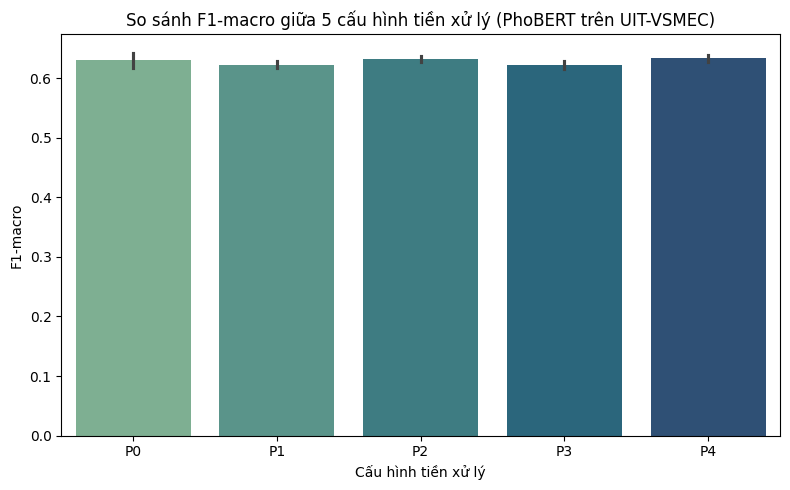

In [22]:
# ==== 9. BIỂU ĐỒ SO SÁNH F1-MACRO GIỮA CÁC CẤU HÌNH ====
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="config", y="f1_macro", order=CONFIGS, errorbar="sd",
            palette="crest")
plt.title("So sánh F1-macro giữa 5 cấu hình tiền xử lý (PhoBERT trên UIT-VSMEC)")
plt.xlabel("Cấu hình tiền xử lý")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/f1_macro_comparison.png", dpi=150)
plt.show()


In [23]:
# ==== 9b. MA TRẬN NHẦM LẪN CHO CẤU HÌNH TỐT NHẤT ====
best_config = summary.sort_values("f1_macro_mean", ascending=False).iloc[0]["config"]
best_seed = results_df[results_df["config"] == best_config].sort_values(
    "f1_macro", ascending=False
).iloc[0]["seed"]
print("Cấu hình tốt nhất:", best_config, "| seed:", best_seed)

# Lưu ý: cần huấn luyện lại hoặc lưu y_true/y_pred lúc chạy để vẽ chính xác.
# Ở đây minh họa cách vẽ nếu bạn lưu lại y_true/y_pred tương ứng.
# cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))
# plt.figure(figsize=(7,6))
# sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
# plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
# plt.title(f"Ma trận nhầm lẫn — {best_config}")
# plt.tight_layout(); plt.savefig("results/confusion_matrix_best.png", dpi=150); plt.show()


Cấu hình tốt nhất: P4 | seed: 123


In [24]:
# ==== 10. KIỂM ĐỊNH THỐNG KÊ: P0 vs P4 (paired t-test + bootstrap) ====
from scipy import stats

p0_scores = results_df[results_df["config"] == "P0"].sort_values("seed")["f1_macro"].values
p4_scores = results_df[results_df["config"] == "P4"].sort_values("seed")["f1_macro"].values

print("P0 F1-macro theo seed:", p0_scores)
print("P4 F1-macro theo seed:", p4_scores)

if len(p0_scores) == len(p4_scores) and len(p0_scores) > 1:
    t_stat, p_value = stats.ttest_rel(p4_scores, p0_scores)
    print(f"Paired t-test P4 vs P0: t = {t_stat:.4f}, p = {p_value:.4f}")
    if p_value < 0.05:
        print("=> Khác biệt có ý nghĩa thống kê (p < 0.05).")
    else:
        print("=> Chưa đủ bằng chứng thống kê để khẳng định khác biệt (p >= 0.05).")
else:
    print("Cần ít nhất 2 seed cho mỗi cấu hình để chạy kiểm định t-test ghép cặp.")

# Bootstrap resampling trên chênh lệch trung bình
rng = np.random.default_rng(42)
diffs = p4_scores - p0_scores if len(p0_scores) == len(p4_scores) else None
if diffs is not None and len(diffs) > 1:
    boot_means = [rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(2000)]
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    print(f"Khoảng tin cậy 95% (bootstrap) của chênh lệch F1-macro (P4 - P0): [{ci_low:.4f}, {ci_high:.4f}]")


P0 F1-macro theo seed: [0.64159383 0.63047133 0.61658884]
P4 F1-macro theo seed: [0.62830721 0.63962551 0.6312104 ]
Paired t-test P4 vs P0: t = 0.4095, p = 0.7219
=> Chưa đủ bằng chứng thống kê để khẳng định khác biệt (p >= 0.05).
Khoảng tin cậy 95% (bootstrap) của chênh lệch F1-macro (P4 - P0): [-0.0133, 0.0146]


## Ghi chú

- **Lưu tiến độ qua Google Drive**: notebook đã được cấu hình để lưu toàn bộ dữ liệu đã tiền xử lý (`cached_datasets/`), kết quả từng lượt chạy (`results/all_results.json`) và checkpoint đang huấn luyện dở lên `MyDrive/PhoBERT_UIT_VSMEC/`. Nếu phiên Colab bị ngắt (hết giờ T4, timeout, mất kết nối...), bạn chỉ cần:
  1. Mở lại notebook, chạy lại **từ cell đầu tiên**.
  2. Ở cell mount Drive, cấp quyền truy cập lại nếu được hỏi.
  3. Các bước đã hoàn tất (tiền xử lý từng cấu hình, các lượt huấn luyện đã xong) sẽ **tự động được bỏ qua**; nếu bị ngắt giữa chừng một lượt huấn luyện, lượt đó sẽ **tự động tiếp tục từ checkpoint gần nhất** thay vì chạy lại từ epoch 0.
- **Thời gian chạy dự kiến**: theo thực tế đo được (~1h20 cho 3 seed của P0, tức ~27 phút/lượt), tổng 15 lượt (5 cấu hình × 3 seed) sẽ mất khoảng **6,5–7 giờ** chạy thực tế — gần như chắc chắn cần chạy qua nhiều phiên Colab.
- **Để chạy thử nhanh trước khi chạy đầy đủ**: sửa `RUN_CONFIGS = ["P0", "P4"]` và `RUN_SEEDS = [42]` ở cell huấn luyện.
- File kết quả cuối cùng: `MyDrive/PhoBERT_UIT_VSMEC/results/ket_qua_tong_hop.xlsx` (bảng thô + bảng tổng hợp trung bình/độ lệch chuẩn + per-class F1 từng lượt chạy) và `.../results/f1_macro_comparison.png`.


In [ ]:
# ==== CẤY LẠI KẾT QUẢ P0/P1/P3 ĐÃ CÓ (từ lần chạy trước trên Drive khác) ====
import json, os, shutil

known_results = [
    {"config": "P0", "seed": 42,   "accuracy": 0.656566, "f1_macro": 0.641594, "f1_weighted": 0.654243},
    {"config": "P0", "seed": 123,  "accuracy": 0.649351, "f1_macro": 0.630471, "f1_weighted": 0.651068},
    {"config": "P0", "seed": 2024, "accuracy": 0.636364, "f1_macro": 0.616589, "f1_weighted": 0.635331},
    {"config": "P1", "seed": 42,   "accuracy": 0.643579, "f1_macro": 0.622922, "f1_weighted": 0.644402},
    {"config": "P1", "seed": 123,  "accuracy": 0.650794, "f1_macro": 0.628326, "f1_weighted": 0.650159},
    {"config": "P1", "seed": 2024, "accuracy": 0.637807, "f1_macro": 0.616655, "f1_weighted": 0.638013},
    {"config": "P3", "seed": 42,   "accuracy": 0.634921, "f1_macro": 0.614471, "f1_weighted": 0.634669},
    {"config": "P3", "seed": 123,  "accuracy": 0.642136, "f1_macro": 0.622078, "f1_weighted": 0.641108},
    {"config": "P3", "seed": 2024, "accuracy": 0.643579, "f1_macro": 0.628654, "f1_weighted": 0.641064},
]

os.makedirs(f"{DRIVE_DIR}/results", exist_ok=True)
results_json_path = f"{DRIVE_DIR}/results/all_results.json"
with open(results_json_path, "w", encoding="utf-8") as f:
    json.dump(known_results, f, ensure_ascii=False, indent=2)

# xóa checkpoint dở dang của P0_seed42 (không cần resume vì đã có kết quả rồi)
shutil.rmtree(f"{DRIVE_DIR}/checkpoints/P0_seed42", ignore_errors=True)

# xóa cache P2/P4 để build lại bằng EMOJI_DICT mới (không dấu "_")
shutil.rmtree(f"{DRIVE_DIR}/cached_datasets/P2", ignore_errors=True)
shutil.rmtree(f"{DRIVE_DIR}/cached_datasets/P4", ignore_errors=True)

print(f"Đã cấy {len(known_results)} kết quả P0/P1/P3, xóa checkpoint dở dang, xóa cache P2/P4 cũ.")
print("Giờ chạy lại: cell module tiền xử lý (sửa EMOJI_DICT) -> cell xây dựng dataset -> cell huấn luyện.")

Đã cấy 9 kết quả P0/P1/P3, xóa checkpoint dở dang, xóa cache P2/P4 cũ.
Giờ chạy lại: cell module tiền xử lý (sửa EMOJI_DICT) -> cell xây dựng dataset -> cell huấn luyện.


# Các phương pháp cải tiến

# 1 Oversampling đơn giản cho lớp hiếm

In [10]:
# ==== OVERSAMPLING CHO LỚP HIẾM (Surprise, Fear) — CHỈ ÁP DỤNG TRÊN TẬP TRAIN ====
import numpy as np
from datasets import Dataset, DatasetDict, concatenate_datasets

TARGET_CONFIG = "P4"          # thử trên cấu hình tốt nhất hiện tại
OVERSAMPLE_TARGET = 800       # số mẫu mong muốn cho mỗi lớp hiếm sau khi nhân bản
MINORITY_LABELS = ["Surprise", "Fear"]

base_ds = datasets_by_config[TARGET_CONFIG]
train_ds = base_ds["train"]

# id2label đã có sẵn từ cell 5; lấy id tương ứng các lớp hiếm
minority_ids = [label2id[l] for l in MINORITY_LABELS]

# tách các mẫu thuộc lớp hiếm và lớp còn lại
train_labels = np.array(train_ds["label"])
minority_mask = np.isin(train_labels, minority_ids)

majority_part = train_ds.select(np.where(~minority_mask)[0].tolist())
minority_part = train_ds.select(np.where(minority_mask)[0].tolist())

print("Phân bố TRƯỚC oversampling (lớp hiếm):")
for lbl in MINORITY_LABELS:
    n = int((train_labels == label2id[lbl]).sum())
    print(f"  {lbl}: {n} mẫu")

# nhân bản từng lớp hiếm riêng biệt lên đúng OVERSAMPLE_TARGET mẫu
oversampled_parts = [majority_part]
rng = np.random.default_rng(42)
for lbl in MINORITY_LABELS:
    lbl_id = label2id[lbl]
    idx = np.where(train_labels == lbl_id)[0]
    n_current = len(idx)
    if n_current >= OVERSAMPLE_TARGET:
        chosen = idx  # đã đủ, không cần nhân bản
    else:
        # lấy hết mẫu gốc + bổ sung thêm bằng cách chọn lặp lại ngẫu nhiên
        extra = rng.choice(idx, size=OVERSAMPLE_TARGET - n_current, replace=True)
        chosen = np.concatenate([idx, extra])
    oversampled_parts.append(train_ds.select(chosen.tolist()))

train_oversampled = concatenate_datasets(oversampled_parts).shuffle(seed=42)

print("\nPhân bố SAU oversampling (lớp hiếm):")
new_labels = np.array(train_oversampled["label"])
for lbl in MINORITY_LABELS:
    n = int((new_labels == label2id[lbl]).sum())
    print(f"  {lbl}: {n} mẫu")
print(f"\nTổng số câu train: {len(train_ds)} -> {len(train_oversampled)}")

# tạo DatasetDict mới: train đã oversample, val/test GIỮ NGUYÊN (không đụng vào)
ds_oversampled = DatasetDict({
    "train": train_oversampled,
    "validation": base_ds["validation"],
    "test": base_ds["test"],
})

Phân bố TRƯỚC oversampling (lớp hiếm):
  Surprise: 242 mẫu
  Fear: 318 mẫu

Phân bố SAU oversampling (lớp hiếm):
  Surprise: 800 mẫu
  Fear: 800 mẫu

Tổng số câu train: 5548 -> 6588


# 1_1 HUẤN LUYỆN P4 + OVERSAMPLING  

In [11]:
# ==== HUẤN LUYỆN THỬ P4 + OVERSAMPLING (1 seed) ====
import torch, random, gc
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

SEED = 42

tokenized_os = ds_oversampled.map(tokenize_function, batched=True)
tokenized_os = tokenized_os.rename_column("label", "labels")
tokenized_os.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS), id2label=id2label, label2id=label2id
)

args = TrainingArguments(
    output_dir="checkpoints/P4_oversampled_seed42",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_os["train"],
    eval_dataset=tokenized_os["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

test_out = trainer.predict(tokenized_os["test"])
y_true = test_out.label_ids
y_pred = np.argmax(test_out.predictions, axis=-1)

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"\n=== KẾT QUẢ P4 + Oversampling (seed 42) ===")
print(f"Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")
print(f"So với P4 gốc (0.6330): {'CẢI THIỆN' if f1_macro > 0.6330 else 'chưa vượt'} ({f1_macro-0.6330:+.4f})")

# per-class để xem Surprise/Fear có cải thiện không
pc_os = per_class_report(y_true, y_pred)
print("\nPer-class F1:")
print(pc_os.to_string(index=False))

del model, trainer
gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/6588 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/693 [00:00<?, ? examples/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== KẾT QUẢ P4 + Oversampling (seed 42) ===
Accuracy: 0.6522 | F1-macro: 0.6322 | F1-weighted: 0.6515
So với P4 gốc (0.6330): chưa vượt (-0.0008)

Per-class F1:
    label  precision   recall       f1  support
    Anger   0.538462 0.525000 0.531646       40
  Disgust   0.620968 0.583333 0.601562      132
Enjoyment   0.748744 0.772021 0.760204      193
     Fear   0.590164 0.782609 0.672897       46
    Other   0.541985 0.550388 0.546154      129
  Sadness   0.716981 0.655172 0.684685      116
 Surprise   0.666667 0.594595 0.628571       37


# 2 THÍ NGHIỆM BỔ SUNG: CLASS WEIGHTS (tách bạch tiền xử lý vs mất cân bằng lớp)

In [ ]:
# ==== 7b. THÍ NGHIỆM BỔ SUNG: CLASS WEIGHTS (tách bạch tiền xử lý vs mất cân bằng lớp) ====
import torch, random, gc, json, os, shutil
import numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# ---- 1. Tính trọng số lớp (inverse frequency) từ tập train GỐC (chưa tiền xử lý) ----
from collections import Counter
label_counts = Counter(raw_ds["train"]["Emotion"])
n_samples = sum(label_counts.values())
n_classes = len(LABELS)

class_weights_list = [
    n_samples / (n_classes * label_counts[label]) for label in LABELS
]
class_weights_tensor = torch.tensor(class_weights_list, dtype=torch.float)

print("Trọng số lớp (theo thứ tự LABELS):")
for lbl, w in zip(LABELS, class_weights_list):
    print(f"  {lbl:12s} (n={label_counts[lbl]:4d}): weight = {w:.3f}")

# ---- 2. Trainer tùy biến: dùng CrossEntropyLoss có trọng số lớp ----
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, len(LABELS)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# ---- 3. Chạy thí nghiệm cho P0 và P4 (so sánh với bản không dùng class weights) ----
CW_CONFIGS = ["P0", "P4"]   # baseline vs cấu hình tiền xử lý tốt nhất
CW_SEEDS = [42, 123, 2024]

RESULTS_DIR = f"{DRIVE_DIR}/results"
CKPT_DIR = f"{DRIVE_DIR}/checkpoints"
PER_CLASS_DIR = f"{RESULTS_DIR}/per_class"
RESULTS_JSON = f"{RESULTS_DIR}/all_results.json"

with open(RESULTS_JSON, "r", encoding="utf-8") as f:
    all_results = json.load(f)
done_runs = {(r["config"], r["seed"]) for r in all_results}

for base_cfg in CW_CONFIGS:
    cw_cfg_name = f"{base_cfg}_CW"   # vd "P0_CW", "P4_CW"
    tokenized = None

    for seed in CW_SEEDS:
        if (cw_cfg_name, seed) in done_runs:
            print(f"Bỏ qua {cw_cfg_name} seed {seed} — đã có kết quả từ phiên trước.")
            continue

        if tokenized is None:
            tokenized = datasets_by_config[base_cfg].map(tokenize_function, batched=True)
            tokenized = tokenized.rename_column("label", "labels")
            tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

        run_name = f"{cw_cfg_name}_seed{seed}"
        run_ckpt_dir = f"{CKPT_DIR}/{run_name}"
        print("=" * 60, "\n>>> Huấn luyện:", run_name, "(có class weights) \n", "=" * 60)

        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=len(LABELS), id2label=id2label, label2id=label2id
        )

        args = TrainingArguments(
            output_dir=run_ckpt_dir,
            num_train_epochs=10,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            eval_strategy="epoch",
            save_strategy="epoch",
            save_total_limit=1,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            logging_steps=50,
            seed=seed,
            report_to=[],
        )

        trainer = WeightedTrainer(
            model=model,
            args=args,
            train_dataset=tokenized["train"],
            eval_dataset=tokenized["validation"],
            compute_metrics=compute_metrics,
            class_weights=class_weights_tensor,
        )

        resume_ckpt = os.path.isdir(run_ckpt_dir) and any(
            d.startswith("checkpoint-") for d in os.listdir(run_ckpt_dir)
        )
        trainer.train(resume_from_checkpoint=resume_ckpt if resume_ckpt else None)

        test_out = trainer.predict(tokenized["test"])
        y_true = test_out.label_ids
        y_pred = np.argmax(test_out.predictions, axis=-1)

        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        all_results.append({
            "config": cw_cfg_name, "seed": seed,
            "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
        })
        done_runs.add((cw_cfg_name, seed))

        pc_df = per_class_report(y_true, y_pred)
        pc_df.to_csv(f"{PER_CLASS_DIR}/{cw_cfg_name}_seed{seed}.csv", index=False)

        with open(RESULTS_JSON, "w", encoding="utf-8") as f:
            json.dump(all_results, f, ensure_ascii=False, indent=2)

        shutil.rmtree(run_ckpt_dir, ignore_errors=True)
        del model, trainer
        gc.collect()
        torch.cuda.empty_cache()

print("Đã hoàn tất thí nghiệm bổ sung class weights.")

Trọng số lớp (theo thứ tự LABELS):
  Anger        (n= 391): weight = 2.027
  Disgust      (n=1071): weight = 0.740
  Enjoyment    (n=1558): weight = 0.509
  Fear         (n= 318): weight = 2.492
  Other        (n=1021): weight = 0.776
  Sadness      (n= 947): weight = 0.837
  Surprise     (n= 242): weight = 3.275


Map:   0%|          | 0/5548 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/693 [00:00<?, ? examples/s]

>>> Huấn luyện: P0_CW_seed42 (có class weights) 


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã hoàn tất thí nghiệm bổ sung class weights.


In [ ]:
# ==== PHÂN TÍCH 2x2: TIỀN XỬ LÝ x CLASS WEIGHTS ====
import pandas as pd
from scipy import stats

results_df = pd.DataFrame(all_results)

def get_scores(cfg):
    return results_df[results_df.config == cfg].sort_values("seed")["f1_macro"].values

p0        = get_scores("P0")
p4        = get_scores("P4")
p0_cw     = get_scores("P0_CW")
p4_cw     = get_scores("P4_CW")

table_22 = pd.DataFrame({
    "Không class weights": [p0.mean(), p4.mean()],
    "Có class weights":    [p0_cw.mean(), p4_cw.mean()],
}, index=["P0 (baseline)", "P4 (tiền xử lý đầy đủ)"])
print("=== Bảng 2x2: F1-macro trung bình ===")
print(table_22.round(4))

print("\n=== Tác động riêng của từng yếu tố ===")
print(f"Hiệu ứng tiền xử lý (P4-P0), KHÔNG class weights: {p4.mean()-p0.mean():+.4f}")
print(f"Hiệu ứng tiền xử lý (P4-P0), CÓ class weights:    {p4_cw.mean()-p0_cw.mean():+.4f}")
print(f"Hiệu ứng class weights, ở P0: {p0_cw.mean()-p0.mean():+.4f}")
print(f"Hiệu ứng class weights, ở P4: {p4_cw.mean()-p4.mean():+.4f}")

t, p = stats.ttest_rel(p0_cw, p0)
print(f"\nP0 vs P0_CW (t-test): t={t:.3f}, p={p:.4f}")
t, p = stats.ttest_rel(p4_cw, p4)
print(f"P4 vs P4_CW (t-test): t={t:.3f}, p={p:.4f}")

=== Bảng 2x2: F1-macro trung bình ===
                        Không class weights  Có class weights
P0 (baseline)                        0.6296            0.6160
P4 (tiền xử lý đầy đủ)               0.6330            0.6288

=== Tác động riêng của từng yếu tố ===
Hiệu ứng tiền xử lý (P4-P0), KHÔNG class weights: +0.0035
Hiệu ứng tiền xử lý (P4-P0), CÓ class weights:    +0.0128
Hiệu ứng class weights, ở P0: -0.0136
Hiệu ứng class weights, ở P4: -0.0042

P0 vs P0_CW (t-test): t=-0.842, p=0.4884
P4 vs P4_CW (t-test): t=-0.486, p=0.6750


# 3 Thí nghiệm cải thiện thử f1 trên P4

In [ ]:
# ==== THỬ NGHIỆM: P4 + LR thấp hơn + warmup + weight decay + early stopping + effective-number class weights ====
import torch, random, gc, numpy as np
from collections import Counter
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

SEED = 42

# ---- 1. Effective Number of Samples class weights (mềm hơn inverse-frequency) ----
BETA = 0.99
label_counts = Counter(raw_ds["train"]["Emotion"])
effective_num = {lbl: 1 - BETA ** label_counts[lbl] for lbl in LABELS}
weights = {lbl: (1 - BETA) / effective_num[lbl] for lbl in LABELS}
w_sum = sum(weights.values())
weights = {lbl: w / w_sum * len(LABELS) for lbl, w in weights.items()}  # chuẩn hóa

class_weights_tensor = torch.tensor([weights[l] for l in LABELS], dtype=torch.float)
print("Effective-number class weights:")
for lbl, w in weights.items():
    print(f"  {lbl:12s}: {w:.3f}")

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, len(LABELS)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# ---- 2. Chuẩn bị dữ liệu P4 (dùng cache đã có) ----
tokenized = datasets_by_config["P4"].map(tokenize_function, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS), id2label=id2label, label2id=label2id
)

# ---- 3. Cấu hình cải tiến ----
args = TrainingArguments(
    output_dir="checkpoints/P4_tuned_seed42",
    num_train_epochs=20,                # tăng epoch, để early stopping tự quyết định điểm dừng
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,                 # giảm từ 2e-5 -> 1e-5
    warmup_ratio=0.1,                   # thêm warmup
    weight_decay=0.01,                  # thêm regularization
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to=[],
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

test_out = trainer.predict(tokenized["test"])
y_true = test_out.label_ids
y_pred = np.argmax(test_out.predictions, axis=-1)

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"\n=== KẾT QUẢ P4_tuned (LR=1e-5, warmup, weight_decay, effective-num weights, early stopping) ===")
print(f"Accuracy:    {acc:.4f}")
print(f"F1-macro:    {f1_macro:.4f}")
print(f"F1-weighted: {f1_weighted:.4f}")
print(f"\nSo với P4 gốc (0.6288 khi có class weights thô, 0.6330 không weights): "
      f"{'CẢI THIỆN' if f1_macro > 0.6330 else 'chưa vượt'} ({f1_macro-0.6330:+.4f})")

del model, trainer
gc.collect()
torch.cuda.empty_cache()

Effective-number class weights:
  Anger       : 0.997
  Disgust     : 0.978
  Enjoyment   : 0.978
  Fear        : 1.019
  Other       : 0.978
  Sadness     : 0.978
  Surprise    : 1.072


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transf

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.802407,1.722498,0.329446,0.101856,0.194197
2,1.389797,1.308728,0.533528,0.309947,0.476140
3,1.122101,1.106782,0.609329,0.470414,0.584468
4,0.924662,1.074325,0.600583,0.524148,0.591266
5,0.745927,1.092788,0.623907,0.560547,0.616781
6,0.625499,1.130264,0.629738,0.575928,0.623471
7,0.574952,1.099589,0.644315,0.594224,0.640828


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== KẾT QUẢ P4_tuned (LR=1e-5, warmup, weight_decay, effective-num weights, early stopping) ===
Accuracy:    0.6522
F1-macro:    0.6190
F1-weighted: 0.6501

So với P4 gốc (0.6288 khi có class weights thô, 0.6330 không weights): chưa vượt (-0.0140)


# 4 TWO-STAGE FINE-TUNING: (1) train trên tập cân bằng -> (2) tinh chỉnh trên tập gốc

In [12]:
# ==== TWO-STAGE FINE-TUNING: (1) train trên tập cân bằng -> (2) tinh chỉnh trên tập gốc ====
import torch, random, gc
import numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

SEED = 42
STAGE1_EPOCHS = 5   # học trên tập ĐÃ oversample (cân bằng hơn)
STAGE2_EPOCHS = 5   # tinh chỉnh lại trên tập GỐC (mất cân bằng thật)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- Chuẩn bị dữ liệu ----
# Stage 1 dùng ds_oversampled (đã tạo ở bước trước: train cân bằng, val/test nguyên bản)
tokenized_stage1 = ds_oversampled.map(tokenize_function, batched=True)
tokenized_stage1 = tokenized_stage1.rename_column("label", "labels")
tokenized_stage1.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Stage 2 dùng datasets_by_config["P4"] gốc (mất cân bằng thật)
tokenized_stage2 = datasets_by_config["P4"].map(tokenize_function, batched=True)
tokenized_stage2 = tokenized_stage2.rename_column("label", "labels")
tokenized_stage2.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# ══════════════════════════════════════════
# STAGE 1 — học trên tập đã cân bằng (oversampling)
# ══════════════════════════════════════════
print("=" * 60, "\n>>> STAGE 1: Huấn luyện trên tập ĐÃ CÂN BẰNG\n", "=" * 60)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS), id2label=id2label, label2id=label2id
)

args_stage1 = TrainingArguments(
    output_dir="checkpoints/P4_twostage_s1",
    num_train_epochs=STAGE1_EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,             # LR bình thường cho giai đoạn học đặc trưng lớp hiếm
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to=[],
)

trainer_stage1 = Trainer(
    model=model,
    args=args_stage1,
    train_dataset=tokenized_stage1["train"],
    eval_dataset=tokenized_stage1["validation"],   # validation GỐC, không oversample
    compute_metrics=compute_metrics,
)
trainer_stage1.train()

# Đánh giá nhanh sau stage 1 (tham khảo, chưa phải kết quả cuối)
test_out_s1 = trainer_stage1.predict(tokenized_stage2["test"])
f1_macro_s1 = f1_score(test_out_s1.label_ids, np.argmax(test_out_s1.predictions, axis=-1),
                        average="macro", zero_division=0)
print(f"\n[Tham khảo] F1-macro sau STAGE 1 (chưa hiệu chỉnh lại): {f1_macro_s1:.4f}")

# Lấy model đã học xong stage 1 để chuyển sang stage 2 (KHÔNG khởi tạo lại từ đầu)
model = trainer_stage1.model

# ══════════════════════════════════════════
# STAGE 2 — tinh chỉnh lại trên tập GỐC (mất cân bằng thật), LR thấp hơn
# ══════════════════════════════════════════
print("\n" + "=" * 60, "\n>>> STAGE 2: Tinh chỉnh lại trên tập GỐC (mất cân bằng)\n", "=" * 60)

args_stage2 = TrainingArguments(
    output_dir="checkpoints/P4_twostage_s2",
    num_train_epochs=STAGE2_EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,             # LR thấp hơn — chỉ hiệu chỉnh nhẹ, tránh quên kiến thức đã học ở stage 1
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to=[],
)

trainer_stage2 = Trainer(
    model=model,                                    # tiếp tục từ model đã học ở stage 1
    args=args_stage2,
    train_dataset=tokenized_stage2["train"],         # train GỐC
    eval_dataset=tokenized_stage2["validation"],
    compute_metrics=compute_metrics,
)
trainer_stage2.train()

# ---- Đánh giá cuối cùng trên tập TEST ----
test_out = trainer_stage2.predict(tokenized_stage2["test"])
y_true = test_out.label_ids
y_pred = np.argmax(test_out.predictions, axis=-1)

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"\n=== KẾT QUẢ TWO-STAGE FINE-TUNING (P4, seed {SEED}) ===")
print(f"Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")
print(f"So với P4 gốc (0.6330):        {'CẢI THIỆN' if f1_macro > 0.6330 else 'chưa vượt'} ({f1_macro-0.6330:+.4f})")
print(f"So với P4+Oversampling (0.6322): {'CẢI THIỆN' if f1_macro > 0.6322 else 'chưa vượt'} ({f1_macro-0.6322:+.4f})")

pc_twostage = per_class_report(y_true, y_pred)
print("\nPer-class F1:")
print(pc_twostage.to_string(index=False))

del model, trainer_stage1, trainer_stage2
gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/5548 [00:00<?, ? examples/s]

>>> STAGE 1: Huấn luyện trên tập ĐÃ CÂN BẰNG


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.105261,1.149601,0.575802,0.492092,0.553831
2,0.819328,1.051305,0.619534,0.560175,0.607057
3,0.657630,1.069964,0.622449,0.584485,0.622948
4,0.498067,1.076389,0.648688,0.608695,0.645416
5,0.470167,1.120722,0.645773,0.609547,0.642363


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== KẾT QUẢ TWO-STAGE FINE-TUNING (P4, seed 42) ===
Accuracy: 0.6580 | F1-macro: 0.6423 | F1-weighted: 0.6572
So với P4 gốc (0.6330):        CẢI THIỆN (+0.0093)
So với P4+Oversampling (0.6322): CẢI THIỆN (+0.0101)

Per-class F1:
    label  precision   recall       f1  support
    Anger   0.583333 0.525000 0.552632       40
  Disgust   0.600000 0.613636 0.606742      132
Enjoyment   0.720000 0.746114 0.732824      193
     Fear   0.688889 0.673913 0.681319       46
    Other   0.580153 0.589147 0.584615      129
  Sadness   0.691667 0.715517 0.703390      116
 Surprise   0.769231 0.540541 0.634921       37


#4_1 TWO-STAGE FINE-TUNING: CHẠY ĐỦ 3 SEED

In [18]:
# ==== TWO-STAGE FINE-TUNING: CHẠY ĐỦ 3 SEED + TỔNG HỢP + KIỂM ĐỊNH THỐNG KÊ ====
import torch, random, gc, json, os
import numpy as np
import pandas as pd
from scipy import stats
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 5
SEEDS = [42, 123, 2024]

RESULTS_DIR = f"{DRIVE_DIR}/results"
TWOSTAGE_JSON = f"{RESULTS_DIR}/twostage_results.json"
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- Nạp lại kết quả two-stage đã có (nếu chạy trước đó bị ngắt) ---
if os.path.exists(TWOSTAGE_JSON):
    with open(TWOSTAGE_JSON, "r", encoding="utf-8") as f:
        twostage_results = json.load(f)
else:
    twostage_results = []

# Cấy sẵn kết quả seed 42 đã có từ trước (tránh chạy lại mất ~30 phút)
if not any(r["seed"] == 42 for r in twostage_results):
    twostage_results.append({
        "config": "P4_twostage", "seed": 42,
        "accuracy": 0.6580, "f1_macro": 0.6423, "f1_weighted": 0.6572,
    })
    with open(TWOSTAGE_JSON, "w", encoding="utf-8") as f:
        json.dump(twostage_results, f, ensure_ascii=False, indent=2)

done_seeds = {r["seed"] for r in twostage_results}

# --- Chuẩn bị dữ liệu (dùng lại ds_oversampled và datasets_by_config["P4"] đã có) ---
tokenized_stage1_base = ds_oversampled.map(tokenize_function, batched=True)
tokenized_stage1_base = tokenized_stage1_base.rename_column("label", "labels")
tokenized_stage1_base.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

tokenized_stage2_base = datasets_by_config["P4"].map(tokenize_function, batched=True)
tokenized_stage2_base = tokenized_stage2_base.rename_column("label", "labels")
tokenized_stage2_base.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

for SEED in SEEDS:
    if SEED in done_seeds:
        print(f"Bỏ qua seed {SEED} — đã có kết quả.")
        continue

    print("=" * 70, f"\n>>> TWO-STAGE FINE-TUNING — SEED {SEED}\n", "=" * 70)
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # ---- Stage 1: học trên tập cân bằng ----
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(LABELS), id2label=id2label, label2id=label2id
    )
    args_s1 = TrainingArguments(
        output_dir=f"{DRIVE_DIR}/checkpoints/P4_twostage_s1_seed{SEED}",
        num_train_epochs=STAGE1_EPOCHS,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=2e-5,
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
        logging_steps=50, seed=SEED, report_to=[],
    )
    trainer_s1 = Trainer(
        model=model, args=args_s1,
        train_dataset=tokenized_stage1_base["train"],
        eval_dataset=tokenized_stage1_base["validation"],
        compute_metrics=compute_metrics,
    )
    trainer_s1.train()
    model = trainer_s1.model

    # ---- Stage 2: tinh chỉnh lại trên tập gốc ----
    args_s2 = TrainingArguments(
        output_dir=f"{DRIVE_DIR}/checkpoints/P4_twostage_s2_seed{SEED}",
        num_train_epochs=STAGE2_EPOCHS,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=1e-5,
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
        logging_steps=50, seed=SEED, report_to=[],
    )
    trainer_s2 = Trainer(
        model=model, args=args_s2,
        train_dataset=tokenized_stage2_base["train"],
        eval_dataset=tokenized_stage2_base["validation"],
        compute_metrics=compute_metrics,
    )
    trainer_s2.train()

    test_out = trainer_s2.predict(tokenized_stage2_base["test"])
    y_true = test_out.label_ids
    y_pred = np.argmax(test_out.predictions, axis=-1)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    twostage_results.append({
        "config": "P4_twostage", "seed": SEED,
        "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
    })
    with open(TWOSTAGE_JSON, "w", encoding="utf-8") as f:
        json.dump(twostage_results, f, ensure_ascii=False, indent=2)

    print(f"\n=== Seed {SEED}: Accuracy={acc:.4f}, F1-macro={f1_macro:.4f}, F1-weighted={f1_weighted:.4f} ===")

    import shutil
    shutil.rmtree(f"{DRIVE_DIR}/checkpoints/P4_twostage_s1_seed{SEED}", ignore_errors=True)
    shutil.rmtree(f"{DRIVE_DIR}/checkpoints/P4_twostage_s2_seed{SEED}", ignore_errors=True)
    del model, trainer_s1, trainer_s2
    gc.collect()
    torch.cuda.empty_cache()

# ══════════════════════════════════════════
# TỔNG HỢP + KIỂM ĐỊNH THỐNG KÊ
# ══════════════════════════════════════════
ts_df = pd.DataFrame(twostage_results).sort_values("seed")
print("\n" + "=" * 70)
print("KẾT QUẢ TWO-STAGE FINE-TUNING — 3 SEED")
print("=" * 70)
print(ts_df.to_string(index=False))
print(f"\nTrung bình: F1-macro = {ts_df['f1_macro'].mean():.4f} ± {ts_df['f1_macro'].std():.4f}")
print(f"            Accuracy = {ts_df['accuracy'].mean():.4f} ± {ts_df['accuracy'].std():.4f}")

# So sánh với P0 gốc (giá trị đã biết từ thực nghiệm trước)
p0_scores = np.array([0.641594, 0.630471, 0.616589])   # F1-macro P0, 3 seed
p4_scores = np.array([0.628307, 0.639625, 0.631210])   # F1-macro P4 gốc (bản đã sửa lỗi emoji), 3 seed -- thay bằng số thật nếu khác
ts_scores = ts_df.sort_values("seed")["f1_macro"].values

print("\n--- Paired t-test: Two-stage vs P0 ---")
t, p = stats.ttest_rel(ts_scores, p0_scores)
diff = ts_scores.mean() - p0_scores.mean()
print(f"Chênh lệch trung bình: {diff:+.4f}")
print(f"t = {t:.3f}, p = {p:.4f}  ->  {'CÓ Ý NGHĨA THỐNG KÊ (p<0.05)' if p < 0.05 else 'chưa đạt ý nghĩa thống kê'}")

rng = np.random.default_rng(42)
diffs = ts_scores - p0_scores
boot = [rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(2000)]
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Bootstrap 95% CI của chênh lệch (Two-stage - P0): [{lo:.4f}, {hi:.4f}]")

Bỏ qua seed 42 — đã có kết quả.
>>> TWO-STAGE FINE-TUNING — SEED 123


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.075265,1.087962,0.590379,0.518607,0.572588
2,0.811045,1.068123,0.620991,0.563591,0.608285
3,0.588772,1.018112,0.644315,0.597025,0.641529
4,0.479468,1.068871,0.637026,0.600279,0.636148
5,0.366257,1.080134,0.644315,0.604409,0.642309


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Seed 123: Accuracy=0.6421, F1-macro=0.6207, F1-weighted=0.6385 ===
Bỏ qua seed 2024 — đã có kết quả.

KẾT QUẢ TWO-STAGE FINE-TUNING — 3 SEED
     config  seed  accuracy  f1_macro  f1_weighted
P4_twostage    42  0.658000  0.642300     0.657200
P4_twostage   123  0.642136  0.620705     0.638484
P4_twostage  2024  0.662338  0.635950     0.660076

Trung bình: F1-macro = 0.6330 ± 0.0111
            Accuracy = 0.6542 ± 0.0106

--- Paired t-test: Two-stage vs P0 ---
Chênh lệch trung bình: +0.0034
t = 0.403, p = 0.7259  ->  chưa đạt ý nghĩa thống kê
Bootstrap 95% CI của chênh lệch (Two-stage - P0): [-0.0098, 0.0194]


In [17]:
# --- Nạp kết quả đã lưu ---
if os.path.exists(TWOSTAGE_JSON):
    with open(TWOSTAGE_JSON, "r", encoding="utf-8") as f:
        twostage_results = json.load(f)
else:
    twostage_results = []

# ==========================================
# XÓA KẾT QUẢ CỦA SEED 123 VÀ 2024
# ==========================================
REMOVE_SEEDS = {123}

twostage_results = [
    r for r in twostage_results
    if r["seed"] not in REMOVE_SEEDS
]

with open(TWOSTAGE_JSON, "w", encoding="utf-8") as f:
    json.dump(twostage_results, f, ensure_ascii=False, indent=2)

print("Đã xóa kết quả của các seed:", REMOVE_SEEDS)

Đã xóa kết quả của các seed: {123}
